# **Car Price EDA Project**

This notebook studies a car price dataset and explains the main patterns in a simple way.

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name - SHIVAM KHANNA**


# **Project Summary -**

This project performs Exploratory Data Analysis (EDA) on a used car prices dataset to understand the factors affecting car selling prices. The dataset was cleaned by checking missing values, duplicates, and unique values before analysis. Different visualizations such as bar charts, histograms, box plots, heatmaps, and scatter plots were used to identify trends, relationships, and outliers. The analysis revealed that factors like MMR value, manufacturing year, vehicle condition, and odometer reading significantly influence the selling price. These insights can help businesses make better pricing decisions, improve inventory management, and support future machine learning models for predicting car prices.

# **GitHub Link -**

[Github Link](https://github.com/khannashivam26/EDA_PROJECT)

# **Problem Statement**

The used car market involves a large number of vehicles with different brands, models, manufacturing years, conditions, mileage, and selling prices. Determining the correct selling price of a used car is a challenging task because many factors influence its market value. Incorrect pricing may result in financial losses, slower sales, or reduced customer satisfaction.

The objective of this project is to perform Exploratory Data Analysis (EDA) on the car prices dataset to understand the characteristics of the data and identify the key factors affecting the selling price of used cars. The analysis focuses on cleaning the data, handling missing values and duplicates, understanding the distribution of variables, identifying outliers, and exploring relationships between different features. By analyzing these patterns, the business can gain valuable insights that support better pricing strategies, inventory management, and decision-making

#### **Define Your Business Objective?**


The primary business objective is to understand the factors that influence the selling price of used cars and use these insights to improve pricing accuracy and business performance. By performing exploratory data analysis, the company can identify which vehicle characteristics—such as **manufacturing year, condition, odometer reading, make, model, transmission type, body type, and MMR (Market Value)**—have the greatest impact on the selling price.

The insights obtained from this analysis can help the business:

* Set fair and competitive prices for used cars.
* Identify high-value and high-demand vehicles.
* Improve inventory planning by stocking vehicles that are more likely to sell quickly.
* Reduce losses caused by overpricing or underpricing vehicles.
* Understand customer preferences and market trends.
* Detect unusual records or outliers that may affect pricing decisions.
* Support data-driven decision-making for dealerships, auctions, and sellers.
* Build a strong foundation for future machine learning models that can accurately predict car selling prices.




# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Dataset Loading

In [2]:
df = pd.read_csv("car_prices.csv/car_prices.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


### Dataset First View

In [3]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


### Dataset Rows & Columns count

In [4]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 558837
Columns: 16


### Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB


#### Duplicate Values

In [6]:
duplicate_count = df.duplicated().sum()
print('Number of duplicate rows:', duplicate_count)

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
condition       11820
odometer           94
color             749
interior          749
mmr                38
sellingprice       12
saledate           12
dtype: int64


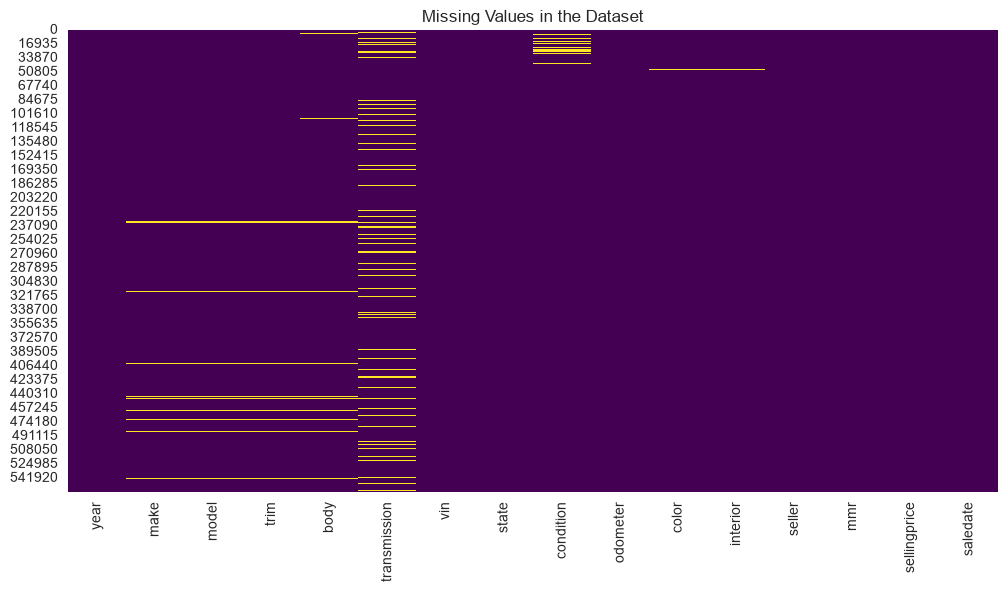

In [10]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in the Dataset')
plt.show()

### What did you know about your dataset?

The dataset has 558,837 rows and 16 columns. It contains no duplicate rows, but several columns have missing values. The most important columns for this analysis are year, make, model, condition, odometer, and sellingprice, because they are useful for understanding car price patterns.

## ***2. Understanding Your Variables***

In [8]:
print(df.columns.tolist())

['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']


In [9]:
df[['year','condition','odometer','mmr','sellingprice']].describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


### Variables Description

The main numerical variables are year, condition, odometer, mmr, and sellingprice. The main categorical variables are make, model, body, transmission, color, interior, and state. These variables help us understand what affects the selling price of a used car.

### Check Unique Values for each variable.

In [10]:
for col in ['make','body','transmission','state','color']:
    if col in df.columns:
        print(f'\nUnique values in {col}:')
        print(df[col].dropna().unique()[:15])


Unique values in make:
<StringArray>
[          'Kia',           'BMW',         'Volvo',        'Nissan',
     'Chevrolet',          'Audi',          'Ford',       'Hyundai',
         'Buick',      'Cadillac',         'Acura',         'Lexus',
      'Infiniti',          'Jeep', 'Mercedes-Benz']
Length: 15, dtype: str

Unique values in body:
<StringArray>
[          'SUV',         'Sedan',   'Convertible',         'Coupe',
         'Wagon',     'Hatchback',      'Crew Cab',       'G Coupe',
       'G Sedan', 'Elantra Coupe', 'Genesis Coupe',       'Minivan',
           'Van',    'Double Cab',   'CrewMax Cab']
Length: 15, dtype: str

Unique values in transmission:
<StringArray>
['automatic', 'manual', 'Sedan', 'sedan']
Length: 4, dtype: str

Unique values in state:
<StringArray>
['ca', 'tx', 'pa', 'mn', 'az', 'wi', 'tn', 'md', 'fl', 'ne', 'nj', 'nv', 'oh',
 'mi', 'ga']
Length: 15, dtype: str

Unique values in color:
<StringArray>
[   'white',     'gray',    'black',      'red',   'silve

## 3. ***Data Wrangling***

### Data Wrangling Code

In [11]:
# Make a copy of the data so we do not change the original file
analysis_df = df.copy()

# Fill missing values with simple placeholders for beginner-friendly analysis
analysis_df['make'] = analysis_df['make'].fillna('Unknown')
analysis_df['model'] = analysis_df['model'].fillna('Unknown')
analysis_df['body'] = analysis_df['body'].fillna('Unknown')
analysis_df['transmission'] = analysis_df['transmission'].fillna('Unknown')
analysis_df['color'] = analysis_df['color'].fillna('Unknown')
analysis_df['interior'] = analysis_df['interior'].fillna('Unknown')
analysis_df['condition'] = analysis_df['condition'].fillna(analysis_df['condition'].median())
analysis_df['odometer'] = analysis_df['odometer'].fillna(analysis_df['odometer'].median())
analysis_df['mmr'] = analysis_df['mmr'].fillna(analysis_df['mmr'].median())
analysis_df['sellingprice'] = analysis_df['sellingprice'].fillna(analysis_df['sellingprice'].median())

# Remove rows where the price is still missing
analysis_df = analysis_df.dropna(subset=['sellingprice'])

# Show the cleaned shape
print('Cleaned data shape:', analysis_df.shape)
print(analysis_df.head())

Cleaned data shape: (558837, 16)
   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0   
1

### What all manipulations have you done and insights you found?

I cleaned the dataset by filling missing values with simple replacements, keeping the data usable for analysis. I also kept the main price-related columns and removed rows with missing price values so the analysis stays reliable.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

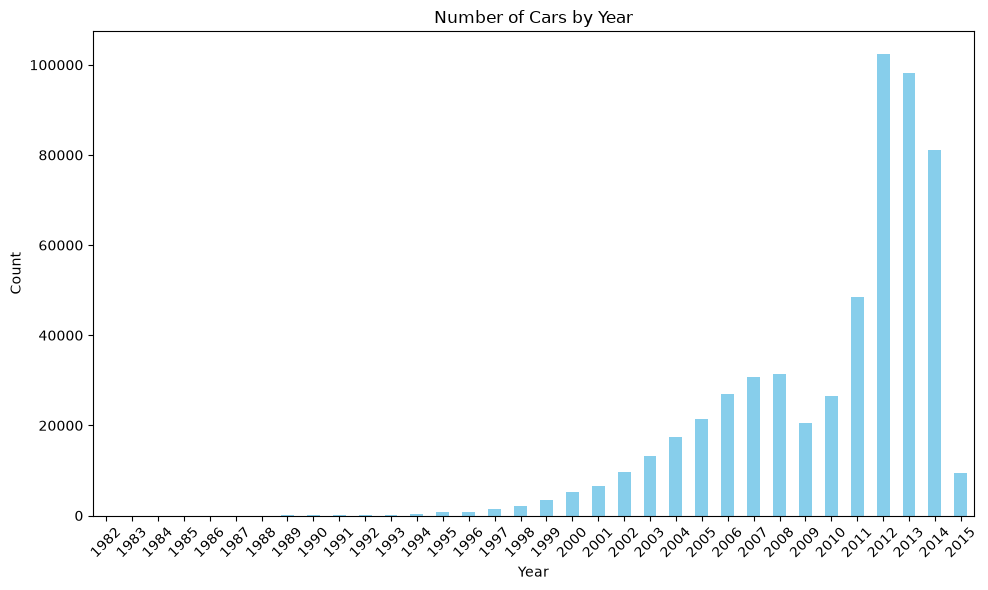

In [12]:
plt.figure(figsize=(10, 6))
analysis_df['year'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Number of Cars by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart because it is simple and easy to read. It helps show which years have more cars in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the dataset has more cars from recent years, especially around 2012 to 2015. This means the data is mostly focused on newer vehicles, so any price pattern we see should be understood in that context.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help businesses because dealers can plan inventory and understand which model years are more common in the market. A possible negative point is that older cars may appear less often, so the business may miss some opportunities in that segment.

#### Chart - 2

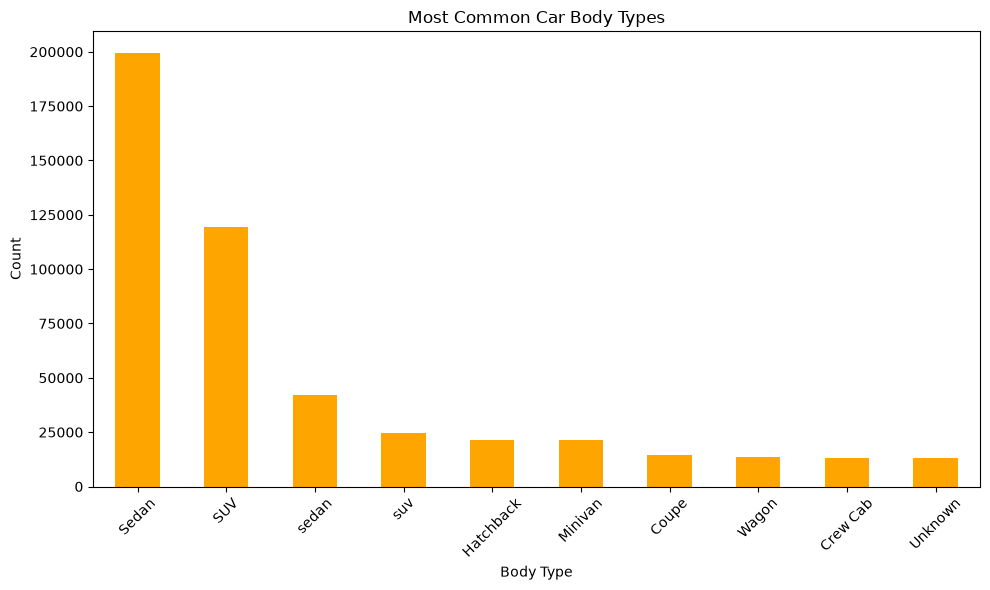

In [13]:
plt.figure(figsize=(10, 6))
analysis_df['body'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Most Common Car Body Types')
plt.xlabel('Body Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a bar chart because it is very easy to understand and works well for comparing categories such as SUV, Sedan, Coupe, and Hatchback. It helps show which body type is most common in the market.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that sedans and SUVs are the most common body types. This is useful because these categories may have more demand and may also affect pricing differently from rarer types such as convertibles or wagons.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help a business focus on the most popular car types. If the market has many sedans and SUVs, dealers can stock more of these vehicles. A negative point is that less common body types may be ignored, which could reduce opportunities in niche markets.

#### Chart - 3

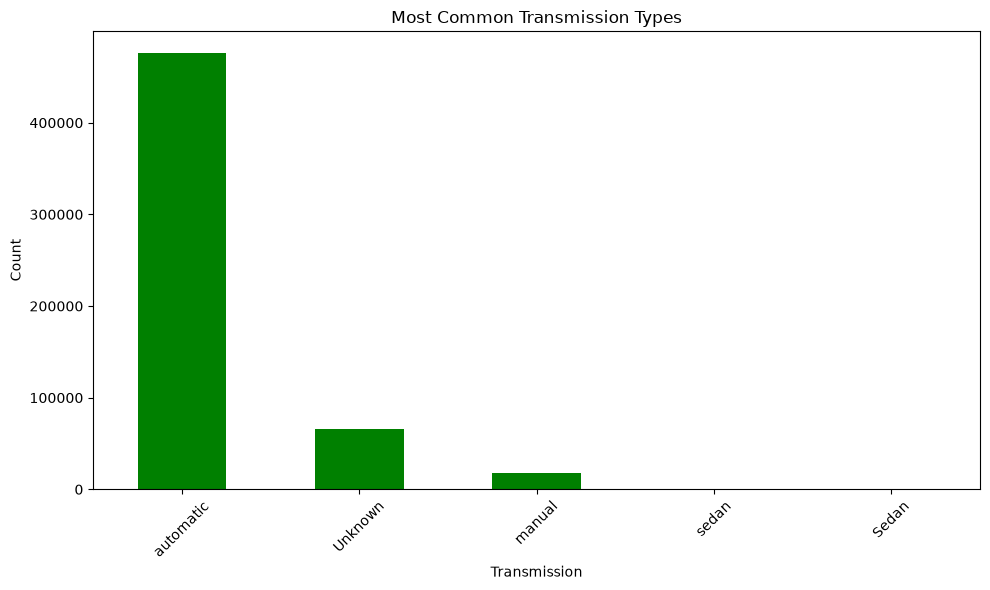

In [14]:
plt.figure(figsize=(10, 6))
analysis_df['transmission'].value_counts().head(10).plot(kind='bar', color='green')
plt.title('Most Common Transmission Types')
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a bar chart again because transmission type is a category, and a bar chart is the best way to compare how many cars use automatic or manual transmission. It is straightforward for beginners.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that automatic transmission cars appear much more often than manual ones. This suggests that the used car market is mostly dominated by automatic vehicles, which can influence pricing and customer demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help businesses understand customer preference. A company can focus more on automatic cars because they are more common. A negative impact may happen if the business ignores manual car buyers, who may still form an important smaller segment.

#### Chart - 4

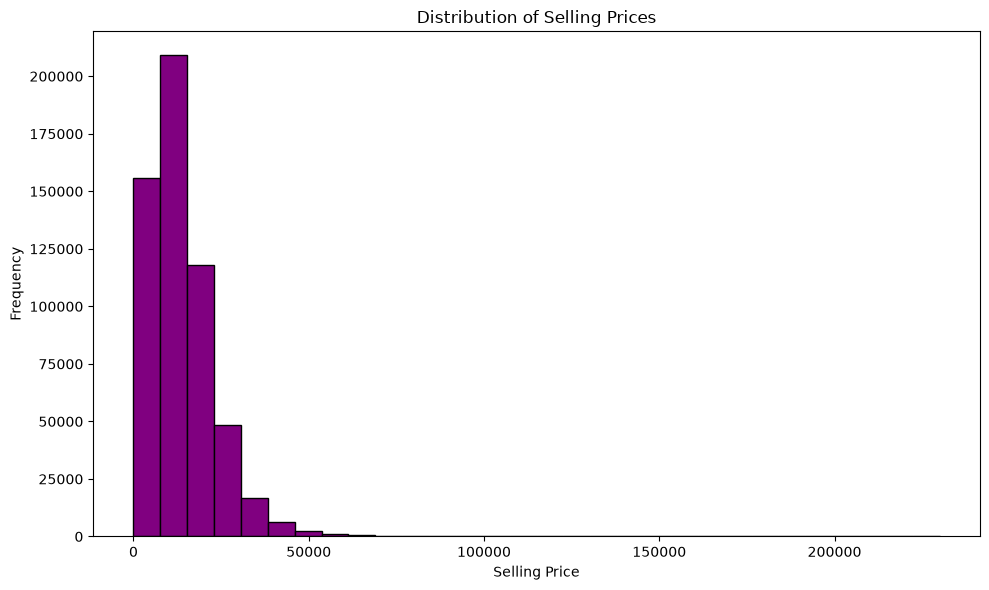

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(analysis_df['sellingprice'], bins=30, color='purple', edgecolor='black')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used a histogram because the selling price is a numerical value. A histogram helps show whether prices are concentrated in a small range or spread across a wide range.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that most cars are sold at lower to mid prices, while only a small number reach very high prices. This tells us that the market has many affordable cars and fewer luxury vehicles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is helpful for pricing strategy. Dealers can use it to understand that most customers may be interested in affordable cars. However, a negative side is that luxury cars may be underrepresented in the data, so some high-end pricing patterns may not be visible.

#### Chart - 5

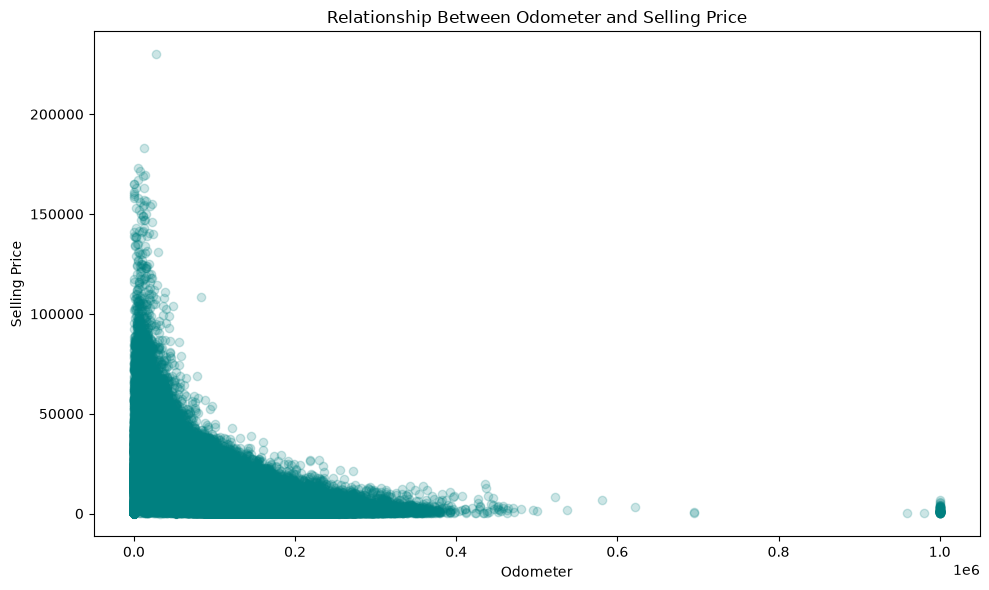

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(analysis_df['odometer'], analysis_df['sellingprice'], alpha=0.2, color='teal')
plt.title('Relationship Between Odometer and Selling Price')
plt.xlabel('Odometer')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to understand the relationship between two numerical variables: odometer and selling price.

##### 2. What is/are the insight(s) found from the chart?

Cars with higher odometer readings generally have lower selling prices, showing a negative relationship. A few outliers are also visible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps dealers estimate car prices based on mileage and make better pricing decisions. Ignoring high-mileage cars may reduce potential sales.

#### Chart - 6

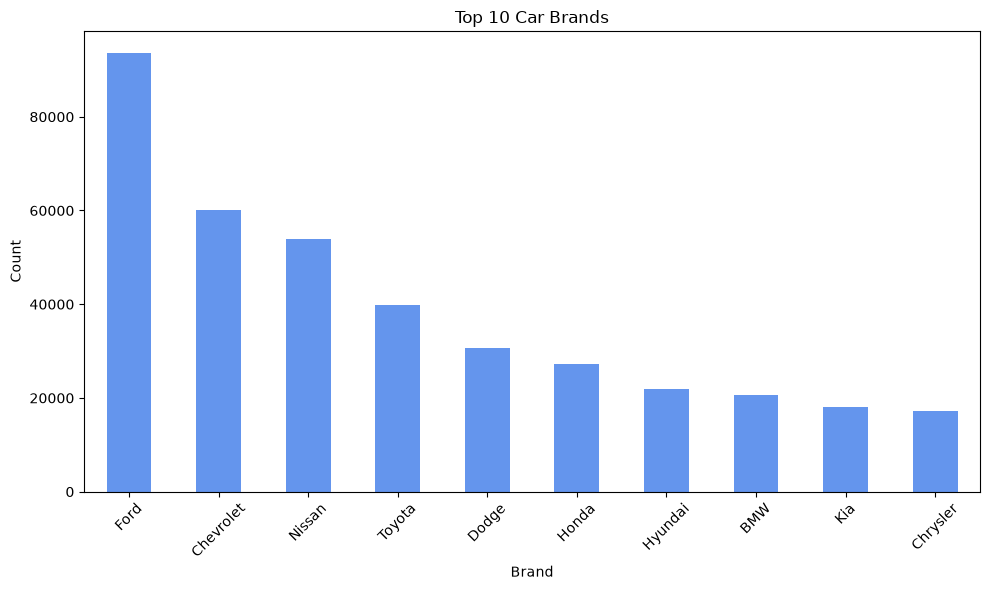

In [17]:
plt.figure(figsize=(10, 6))
analysis_df['make'].value_counts().head(10).plot(kind='bar', color='cornflowerblue')
plt.title('Top 10 Car Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose this chart because brand names are categories, and a bar chart helps compare them quickly. It is easy for beginners to understand and shows which brands are most common.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some brands appear more often than others. This tells us that the market has a strong presence of certain manufacturers, which may affect price trends and customer interest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help a business decide which brands to highlight in marketing or inventory planning. A possible negative side is that less common brands may receive less attention, even if they could attract a niche audience.

#### Chart - 7

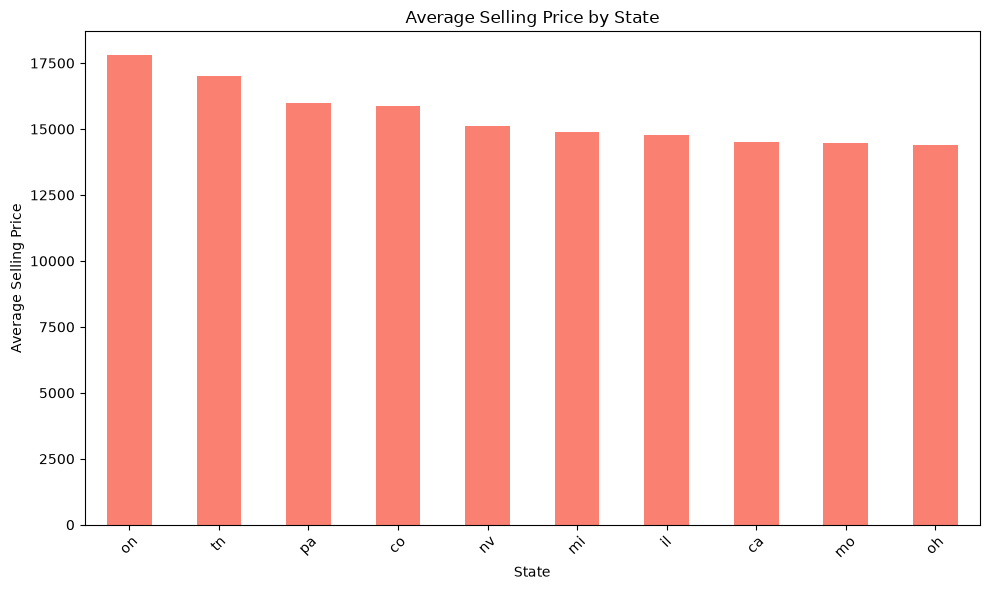

In [18]:
plt.figure(figsize=(10, 6))
analysis_df.groupby('state')['sellingprice'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='salmon')
plt.title('Average Selling Price by State')
plt.xlabel('State')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart because we are comparing average price across different states. A bar chart is easier to read than a table when we want to quickly spot the highest and lowest values.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some states have higher average selling prices than others. This may happen because of market demand, local income levels, or vehicle availability in each state.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help businesses focus on regions where cars are sold at higher prices. It can also support better pricing decisions. A negative point is that states with lower average prices may be ignored, even though they may still represent strong sales volume.

#### Chart - 8

<Figure size 1000x600 with 0 Axes>

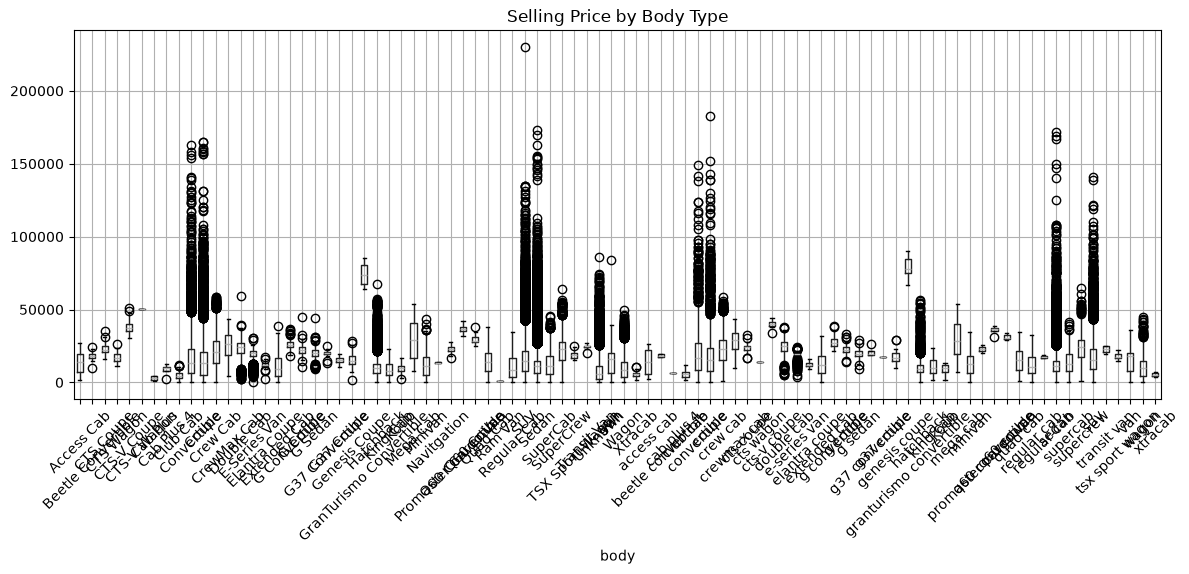

In [19]:
plt.figure(figsize=(10, 6))
analysis_df.boxplot(column='sellingprice', by='body', figsize=(12, 6))
plt.title('Selling Price by Body Type')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is useful for comparing the distribution of selling prices across different body types and identifying outliers.

##### 2. What is/are the insight(s) found from the chart?

Some body types have higher median selling prices than others, and price variation differs across body types. Outliers are also present.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, businesses can focus on body types with higher value and demand. Less popular body types may generate lower revenue.

#### Chart - 9

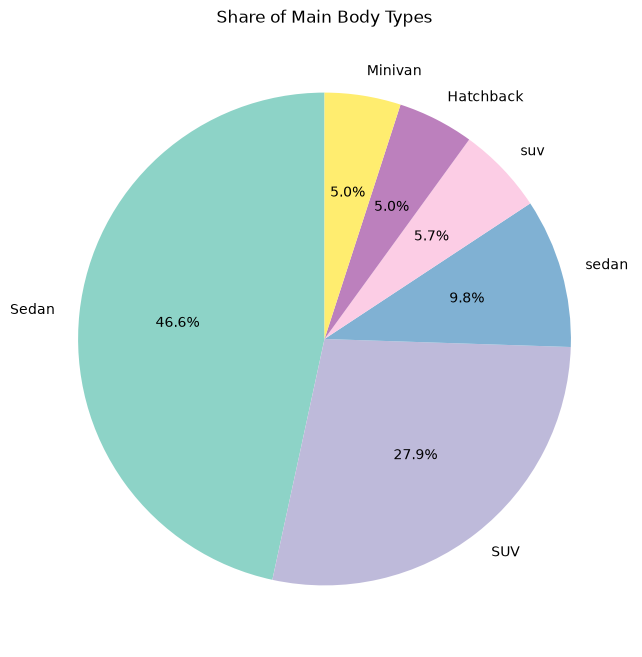

In [20]:
plt.figure(figsize=(8, 8))
analysis_df['body'].value_counts().head(6).plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Set3')
plt.title('Share of Main Body Types')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

I used a pie chart because it is a simple way to show how much of the data belongs to each body type. It helps us quickly see the biggest groups.

##### 2. What is/are the insight(s) found from the chart?

The pie chart shows that a few body types make up most of the dataset. This helps us understand which categories are most common in the used car market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can support better stock planning and marketing choices. A possible drawback is that rare body types may look less important, even if they are valuable to a smaller customer group.

#### Chart - 10

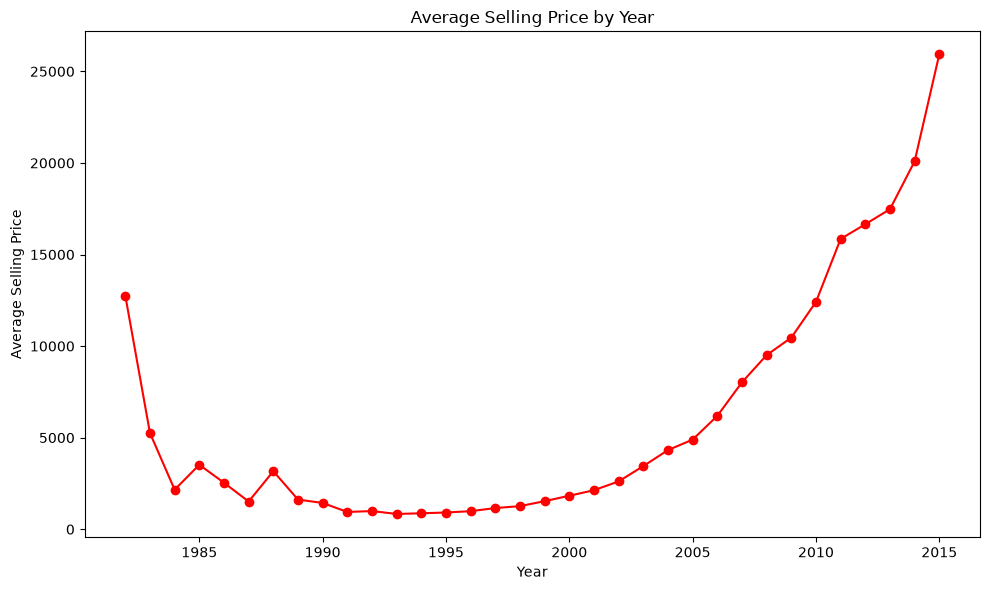

In [21]:
plt.figure(figsize=(10, 6))
price_by_year = analysis_df.groupby('year')['sellingprice'].mean()
price_by_year.plot(kind='line', marker='o', color='red')
plt.title('Average Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used a line chart because it is great for showing change over time. It helps us see whether average prices increase or decrease as the year changes.

##### 2. What is/are the insight(s) found from the chart?

The line chart shows that average selling price changes over time. This suggests that newer or different model years may have different price levels, which is helpful for pricing decisions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help businesses understand price trends over time. It can also support better planning for inventory and promotions. A negative point is that one year may not represent the full market if the dataset has fewer cars for that year.

#### Chart - 11

<Figure size 1000x600 with 0 Axes>

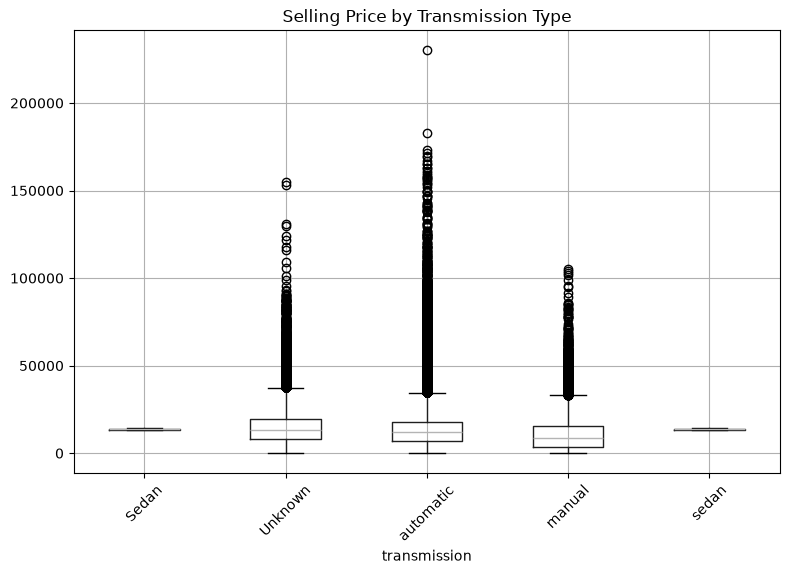

In [22]:
plt.figure(figsize=(10, 6))
analysis_df.boxplot(column='sellingprice', by='transmission', figsize=(8, 6))
plt.title('Selling Price by Transmission Type')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used a box plot because it shows the price range and the middle values for each transmission type. It is helpful for spotting whether one category has much higher or lower prices.

##### 2. What is/are the insight(s) found from the chart?

The box plot shows that transmission type may affect the price range. It helps us see whether automatic cars are more expensive or have a wider spread of prices compared with manual cars.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can support pricing strategy and customer targeting. A possible negative impact is that the chart may not fully reflect the market if the dataset has many missing or unusual values in that category.

#### Chart - 12

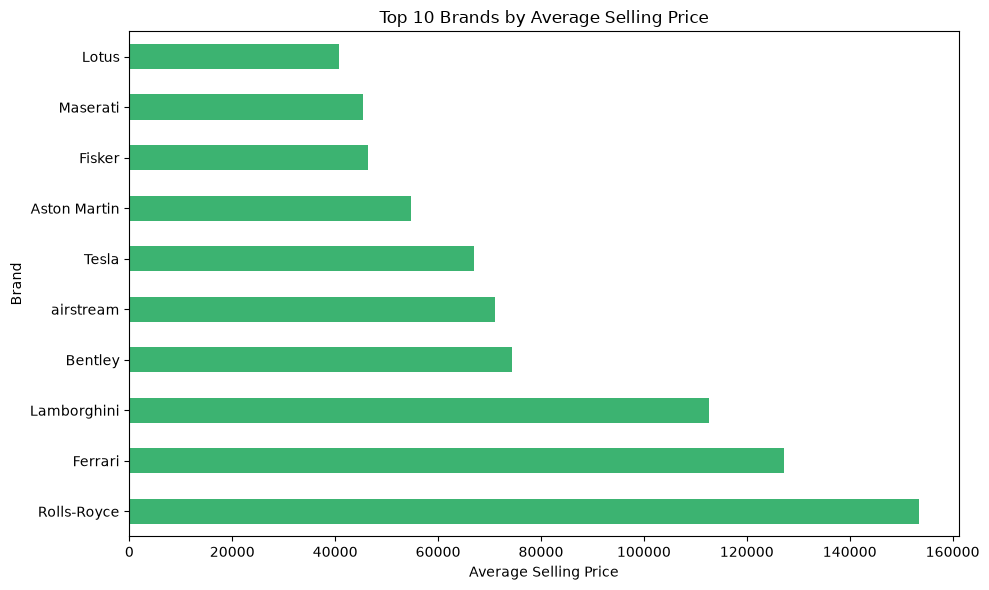

In [23]:
plt.figure(figsize=(10, 6))
analysis_df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10).plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Brands by Average Selling Price')
plt.xlabel('Average Selling Price')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used a horizontal bar chart because it makes it easier to read the names of brands and compare their average prices clearly. This is beginner friendly and visually simple.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some brands have higher average selling prices than others. This suggests that brand reputation and vehicle type may strongly affect market value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help a company focus on premium brands or plan better pricing for different segments. A negative point is that lower-priced brands may appear less attractive, even though they may still generate strong sales volume.

#### Chart - 13

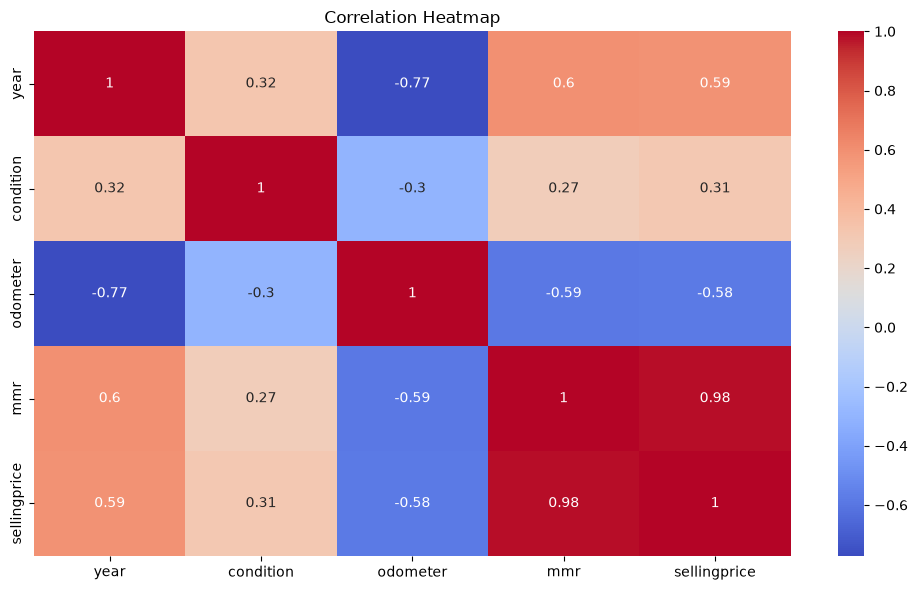

In [24]:
plt.figure(figsize=(10, 6))
correlation = analysis_df[['year','condition','odometer','mmr','sellingprice']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a heatmap because it is a simple way to see strong or weak relationships between numbers. It helps us quickly understand which variables move together.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that selling price is strongly related to market price estimate (MMR) and also has a noticeable relationship with age and mileage. This means price is not controlled by one factor alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is useful for business because it helps identify the strongest price drivers. It can improve pricing models and support better decision making. A negative point is that correlation does not prove cause and effect, so it should be used carefully.

#### Chart - 14 - Correlation Heatmap

<Figure size 1000x600 with 0 Axes>

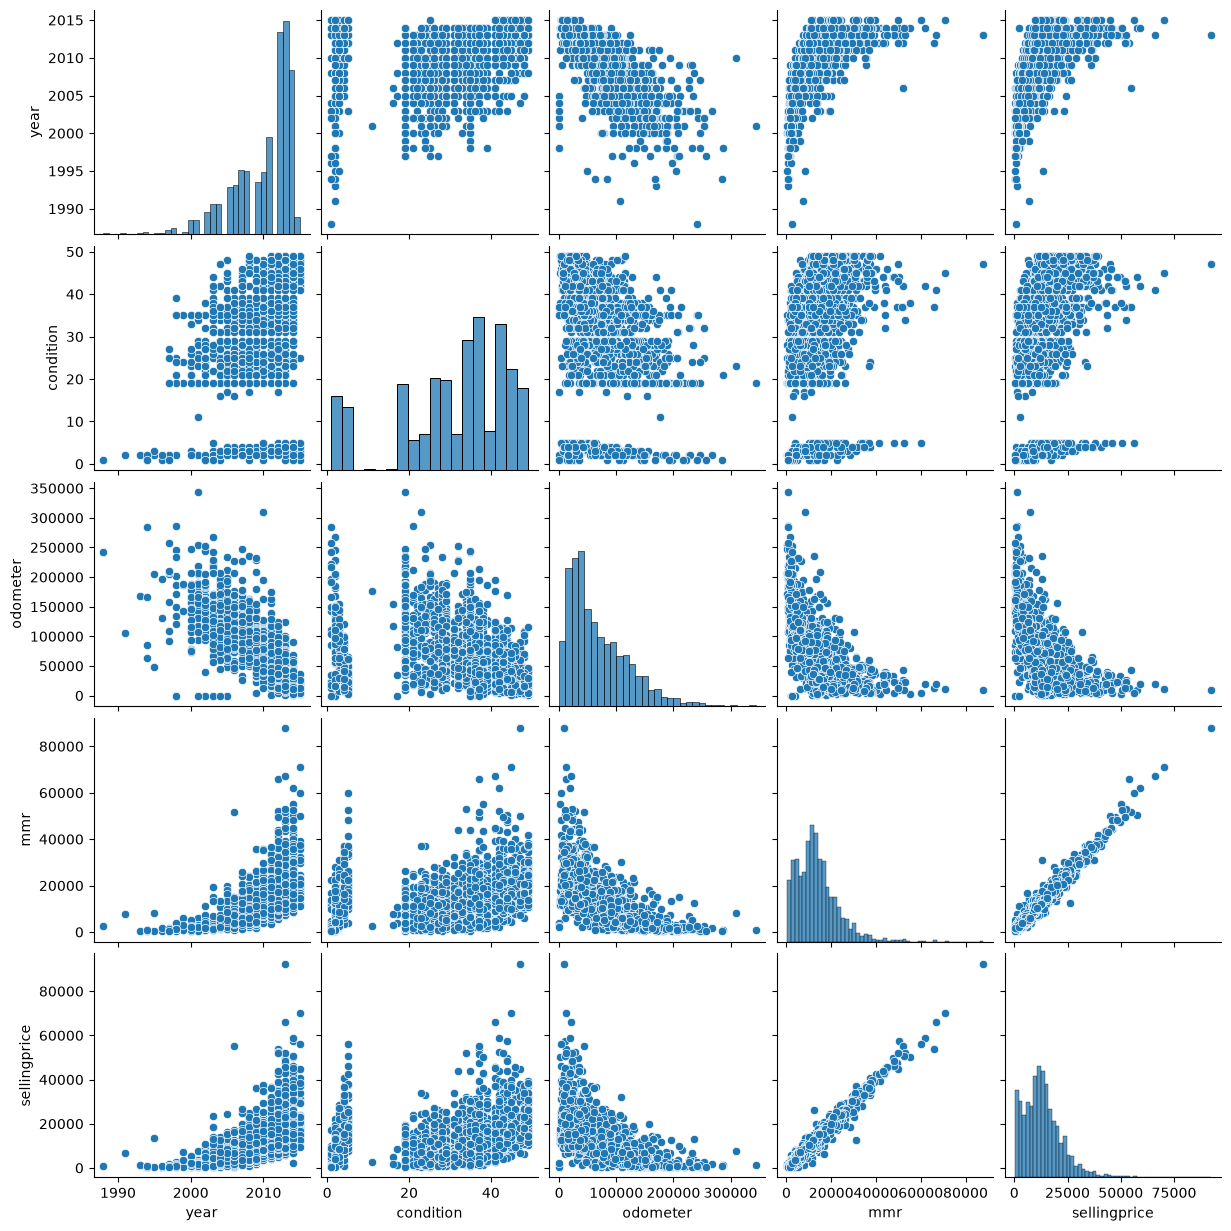

In [25]:
plt.figure(figsize=(10, 6))
selected_columns = ['year','condition','odometer','mmr','sellingprice']
sns.pairplot(analysis_df[selected_columns].sample(2000, random_state=42))
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize relationships among all numerical variables and observe their distributions together.

##### 2. What is/are the insight(s) found from the chart?

MMR and selling price show a strong positive relationship. Higher odometer values are associated with lower selling prices, while newer cars generally sell for more.

#### Chart - 15 - Pair Plot

In [29]:
# Pair Plot visualization code


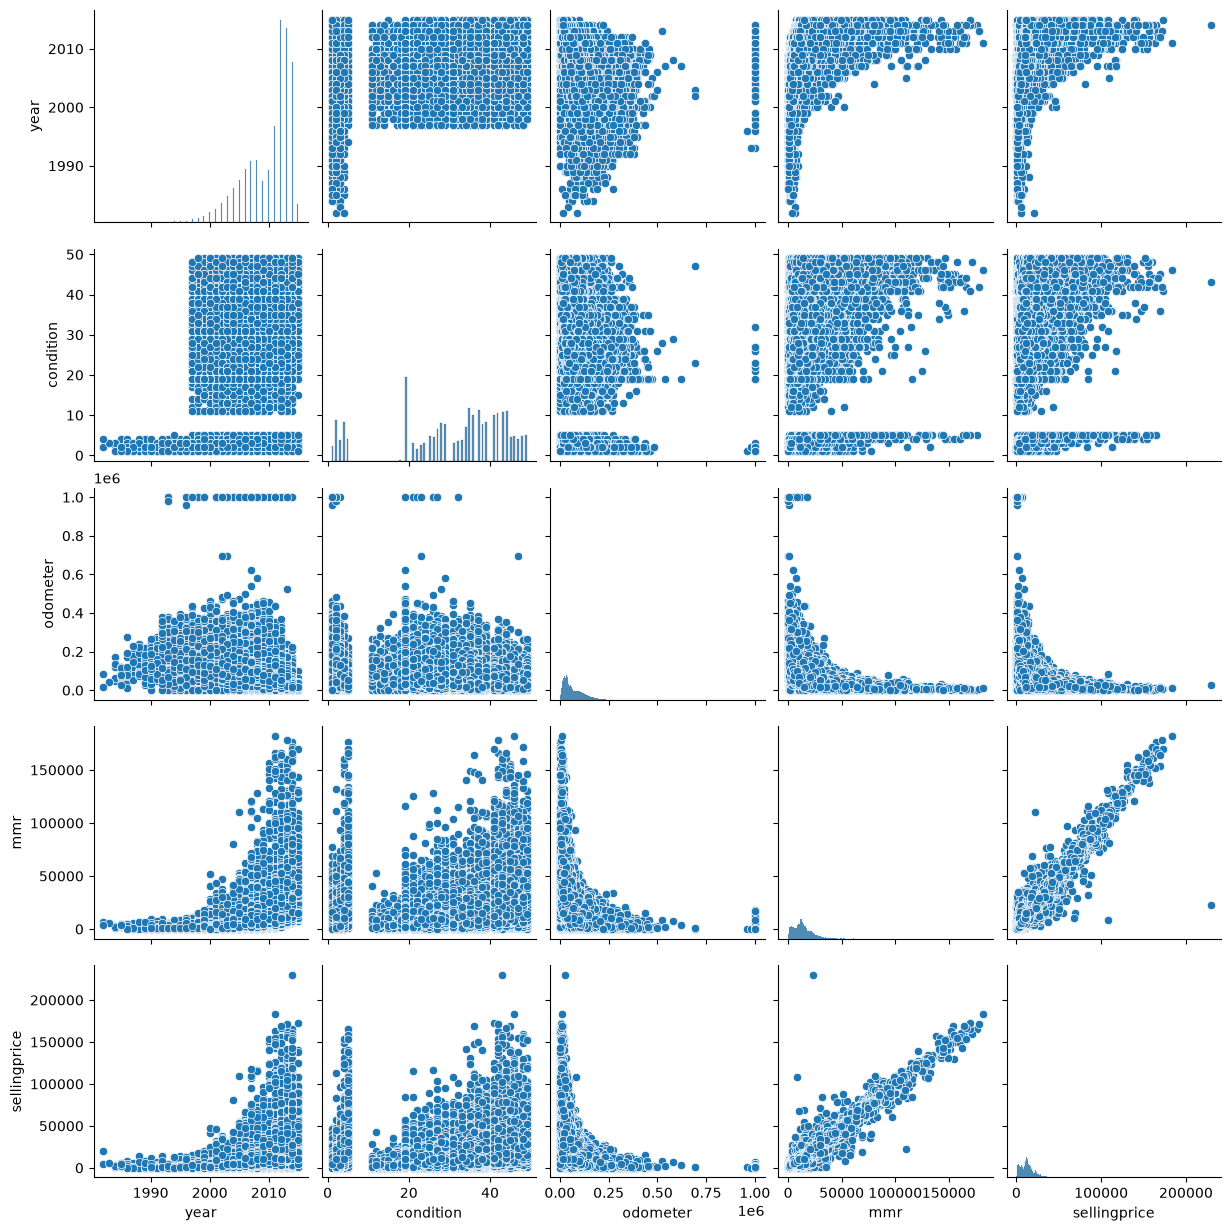

In [26]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

A Pair Plot was used to visualize the relationships between all numerical variables at once. It also shows the distribution of each variable and helps identify correlations and outliers.

##### 2. What is/are the insight(s) found from the chart?

MMR and Selling Price have a strong positive relationship.
Higher odometer readings generally lead to lower selling prices.
Newer cars tend to have higher selling prices.
The chart also helps identify data patterns and outliers.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

The main objective of the client should be to understand the factors that affect car selling prices and use these insights to improve pricing decisions. The analysis shows that variables such as MMR value, vehicle age, odometer reading, and condition have a significant impact on the selling price.

The client should focus on maintaining accurate vehicle pricing, identifying high-value vehicles, and reducing losses caused by incorrect pricing. Understanding customer preferences and vehicle characteristics can also help improve inventory management and increase overall profitability.

The insights from this analysis can be used to:

- Set more accurate selling prices.
- Improve inventory planning.
- Increase profits by focusing on high-demand vehicles.
- Support better business decisions using data.

# **Conclusion**

The exploratory data analysis (EDA) of the car prices dataset provided valuable insights into the factors that influence vehicle selling prices. Throughout the analysis, different visualizations were used to understand the distribution of variables, relationships between features, and trends present in the data. It was observed that variables such as MMR value, vehicle age, odometer reading, and vehicle condition have a significant impact on the selling price. Newer vehicles with lower mileage generally sell for higher prices, while older vehicles with higher mileage tend to have lower selling prices.

The analysis also helped identify outliers, missing values, and overall data patterns, which are important for improving data quality before building machine learning models. These findings can help businesses make better pricing decisions, manage inventory more efficiently, and focus on vehicles that generate higher profits. Overall, EDA serves as a strong foundation for predictive analysis and supports data-driven business decisions that can improve sales performance and customer satisfaction.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***